# 本次模擬cmd log資訊

* 只保留run.log最後200行的資訊和AMReX finalize(如下)


In [20]:
start_time = None
end_time = None
elapsed = None

with open("run.log") as f:
    for line in f:
        line = line.strip()

        if line.startswith("START:"):
            start_time = line.replace("START:", "").strip()

        elif line.startswith("END:"):
            end_time = line.replace("END:", "").strip()

        elif line.startswith("Total run time"):
            elapsed = line.replace("Total run time", "").strip()

print("Simulation Information")
print("----------------------")
print(f"Start Time : {start_time}")
print(f"End Time   : {end_time}")
print(f"Run Time   : {elapsed}")

Simulation Information
----------------------
Start Time : None
End Time   : None
Run Time   : 10187.59369 seconds


# 使用者設定

In [18]:
import re
from pathlib import Path

import yt
import numpy as np
import pandas as pd


# =========================
# User settings
# =========================#"/home/gkaiwi58/FAM/FerroX/Exec/MFIM_mod_1/"
PLOT_DIR = Path("./plts")          # plotfile 所在資料夾
PLOT_PREFIX = "plt"
PLOT_INTERVAL = 10000000           # 你的 plot_int，例如 100

# 如果你的 field 名稱不是 ("boxlib", "Phi")，後面會自動列出 field_list 方便你改
PHI_FIELD_CANDIDATES = [
    ("boxlib", "Phi"),
    ("boxlib", "phi"),
    ("boxlib", "PoissonPhi"),
    "Phi",
    "phi",
    "PoissonPhi",
]

wanted = {"alpha", "beta", "gamma", "BigGamma", "g11", "g44", "FE_lo", "FE_hi"}

def parse_value(values):
    vals = [float(v) for v in values.split()]
    return vals[0] if len(vals) == 1 else vals

params = {}

with open("inputs") as f:
    for line in f:
        line = line.strip()
        if not line or "=" not in line:
            continue

        key, values = line.split("=", 1)
        if key.strip() in wanted:
            params[key.strip()] = parse_value(values.strip())

# FE layer range, unit: nm
FE_Z_LO_NM = params["FE_lo"][2] / 1e-9
FE_Z_HI_NM = params["FE_hi"][2] / 1e-9

# 如果你想只畫 FE 的 x 範圍，也可以打開這兩行
# 若是 MFIS 全幅 FE，通常用整個 x 範圍即可

FE_X_LO_NM = params["FE_lo"][0] / 1e-9
FE_X_HI_NM = params["FE_hi"][0] / 1e-9

FE_Y_LO_NM = params["FE_lo"][1] / 1e-9
FE_Y_HI_NM = params["FE_hi"][1] / 1e-9

ALPHA = params["alpha"]
BETA = params["beta"]
SMALL_GAMMA = params["gamma"]
BIG_GAMMA = params["BigGamma"]
G11 = params["g11"]
G44 = params["g44"]
T_FE = 1e-9 * (FE_Z_HI_NM - FE_Z_LO_NM)  # FE layer thickness, unit: m

print("Parameters:")
print(f"  ALPHA = {ALPHA:.3e}")
print(f"  BETA = {BETA:.3e}")
print(f"  SMALL_GAMMA = {SMALL_GAMMA:.3e}")
print(f"  BIG_GAMMA = {BIG_GAMMA:.3e}")
print(f"  G11 = {G11:.3e}")
print(f"  G44 = {G44:.3e}")
print(f"  FE layer thickness = {T_FE:.3e} m")
# 3D sweep plot要畫的電壓欄位：-4.5, -4.0, ..., 4.5
VOLTAGES = np.arange(-4.5, 5.0, 0.5)
# 3D contour 要畫的plotfile


Parameters:
  ALPHA = -6.250e+09
  BETA = 1.000e+11
  SMALL_GAMMA = 1.500e+11
  BIG_GAMMA = 1.000e+02
  G11 = 1.000e-09
  G44 = 1.000e-09
  FE layer thickness = 7.000e-09 m


## Utils

In [19]:
def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names

In [ ]:
from pathlib import Path
import yt


plot_paths = sorted([p for p in PLOT_DIR.glob(f"{PLOT_PREFIX}*") if p.is_dir()])

# 只要名稱 (plt000100, ...)
plot_names = [p.name for p in plot_paths]

print("Available plotfiles:")
for name in plot_names:
    print("  ", name)
    
print(len(plot_names), "plotfiles found in", PLOT_DIR)
PLOTFILE_NAME = plot_names[30] 


Available plotfiles:
   plt00000000
   plt00002422
   plt00003645
   plt00004774
   plt00006883
   plt00009592
   plt00012462
   plt00014494
   plt00015840
   plt00018205
   plt00020093
   plt00022955
   plt00026316
   plt00027694
   plt00030071
   plt00031578
   plt00033440
   plt00034690
   plt00035569
   plt00037030
   plt00037516
   plt00038889
   plt00040164
   plt00041394
   plt00051721
   plt00052832
   plt00055558
   plt00057377
   plt00062509
   plt00064526
   plt00065657
   plt00066691
   plt00075729
   plt00077011
   plt00077900
   plt00078638
   plt00079430
   plt00079828
   plt00080283
   plt00081549
   plt00082253
   plt00085378
   plt00088310
   plt00089957
   plt00108642
   plt00111528
   plt00114095
47 plotfiles found in /home/gkaiwi58/FAM/FerroX/Exec/MFIS_t_8_nomi


## 探索yt資料結構

### dir(ds) # 列出 ds 所有(variable和property和method)

* Note: variable和property和method統稱attribute

In [32]:
ds = yt.load(PLOT_DIR/plot_names[0])  # 載入指定的 plotfile
dir(ds) # 列出 ds 所有變數和屬性和方法
#[a for a in dir(ds) if not a.startswith("_")]

yt : [INFO     ] 2026-06-25 19:58:48,502 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-25 19:58:48,503 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:58:48,503 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:58:48,503 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


['__abstractmethods__',
 '__annotate_func__',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getitem__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__iter__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__slots__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_abc_impl',
 '_add_object_class',
 '_arr',
 '_assign_unit_system',
 '_create_unit_registry',
 '_default_cparam_filename',
 '_determined_fields',
 '_field_info',
 '_field_info_class',
 '_field_list',
 '_find_extremum',
 '_force_periodicity',
 '_get_field_info',
 '_get_field_info_helper',
 '_guess_candidates',
 '_hash',
 '_header_mesh_start',
 '_index_class',
 '_input_filename',
 '_instantiated',
 '_instantiated_index',
 '_ionization_label_format',
 '_is_valid',
 '_is_withi

### 用key word查看dir(ds)中可能會用到的attribute

In [33]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "domain"
    if "domain" in a.lower():
        print(a)

_is_within_domain
domain_center
domain_dimensions
domain_left_edge
domain_offset
domain_right_edge
domain_width


In [34]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "field"
    if "field" in a.lower():
        print(a)

_determined_fields
_field_info
_field_info_class
_field_list
_get_field_info
_get_field_info_helper
add_deposited_particle_field
add_field
add_gradient_fields
add_mesh_sampling_particle_field
create_field_info
default_field
default_species_fields
derived_field_list
field_info
field_list
field_units
fields
fields_detected
find_field_values_at_point
find_field_values_at_points
particle_fields_by_type
set_field_label_format
setup_deprecated_fields


In [35]:
for a in dir(ds): # 列出 ds 裡有哪些屬性和方法，特別是包含 "index"
    if "index" in a.lower():
        print(a)

_index_class
_instantiated_index
index


* **grid相關attribute在index內**

In [36]:
for a in dir(ds.index): # 列出 ds.index 裡有哪些屬性和方法，特別是包含 "index"
    if "grid" in a.lower():
        print(a)

_count_grids
_get_grid_objs
_get_grid_tree
_get_grids
_grid_chunksize
_grids
_initialize_grid_arrays
_populate_grid_objects
grid
grid_corners
grid_dimensions
grid_left_edge
grid_levels
grid_particle_count
grid_right_edge
grid_start_index
grids
lock_grids_to_parents
num_grids
select_grids


In [37]:
for a in dir(ds.index.grids[0]): # 列出 ds.index.grids[0] 裡有哪些屬性和方法，特別是包含 "index"
    
        print(a)

ActiveDimensions
Children
LeftEdge
Level
NumberOfParticles
OverlappingSiblings
Parent
RightEdge
__abstractmethods__
__add__
__and__
__annotate_func__
__class__
__delattr__
__delitem__
__dict__
__dir__
__doc__
__eq__
__firstlineno__
__format__
__ge__
__getattribute__
__getitem__
__getstate__
__gt__
__hash__
__init__
__init_subclass__
__int__
__invert__
__le__
__lt__
__module__
__ne__
__new__
__or__
__reduce__
__reduce_ex__
__repr__
__setattr__
__setitem__
__sizeof__
__slots__
__static_attributes__
__str__
__sub__
__subclasshook__
__weakref__
__xor__
_abc_impl
_activate_cache
_base_offset
_cache_mask
_child_index_mask
_child_indices
_child_mask
_children_ids
_chunk_info
_chunked_read
_compute_extrema
_con_args
_container_fields
_count_particles
_current_chunk
_current_fluid_type
_current_particle_type
_data_source
_debug
_default_field_parameters
_derived_quantity_chunking
_determine_fields
_distributed
_ds_hold
_extrema_cache
_field_cache
_field_lock
_field_parameter_state
_field_type_s

## yt dataset

* 可以從上一個部份"探索yt資料結構"找想用的attribute

In [38]:
print("========== Dataset ==========")
print("type:", type(ds))
print("用SI單位")
print("current_time(s):", ds.current_time)
print("domain_left_edge(m) :", ds.domain_left_edge)
print("domain_right_edge(m):", ds.domain_right_edge)
print("domain_center:", ds.domain_center)
print("domain_width(domain邊長):", ds.domain_width)
print("domain_offset:", ds.domain_offset)
print("domain_dimensions(xyz方向各切成幾格):", ds.domain_dimensions)
print("dimensionality:", ds.dimensionality)
print("geometry:", ds.geometry)
#print("periodicity:", ds.periodicity)

print("\n========== Fields ==========")
for f in ds.field_list:
    print(" ", f)


========== Dataset ==========
type: <class 'yt.frontends.amrex.data_structures.BoxlibDataset'>
用SI單位
current_time(s): 0.0 code_time
domain_left_edge(m) : [-1.6e-08 -1.6e-08  0.0e+00] code_length
domain_right_edge(m): [1.60e-08 1.60e-08 2.95e-08] code_length
domain_center: [0.000e+00 0.000e+00 1.475e-08] code_length
domain_width(domain邊長): [3.20e-08 3.20e-08 2.95e-08] code_length
domain_offset: [0 0 0]
domain_dimensions(xyz方向各切成幾格): [64 64 59]
dimensionality: 3
geometry: cartesian

========== Fields ==========
  ('boxlib', 'Ex')
  ('boxlib', 'Ey')
  ('boxlib', 'Ez')
  ('boxlib', 'Phi')
  ('boxlib', 'PhiDiff')
  ('boxlib', 'PoissonRHS')
  ('boxlib', 'Px')
  ('boxlib', 'Py')
  ('boxlib', 'Pz')
  ('boxlib', 'alpha')
  ('boxlib', 'beta')
  ('boxlib', 'charge')
  ('boxlib', 'electrons')
  ('boxlib', 'epsilon')
  ('boxlib', 'holes')
  ('boxlib', 'mask')
  ('boxlib', 'theta')
  ('boxlib', 'tphase')


* domain切成多個grid分配給mpi rank平行運算，**資料分散在每個grid**

In [39]:
print("\n========== Grids ==========")
print("number of grids:", len(ds.index.grids))
for i, g in enumerate(ds.index.grids):
    print(f"grid {i}:")
    print("  LeftEdge:", g.LeftEdge)
    print("  RightEdge:", g.RightEdge)
    print("  ActiveDimensions:", g.ActiveDimensions)
    print("  Level:", g.Level)
print(ds.index.grid_start_index)


========== Grids ==========
number of grids: 16
grid 0:
  LeftEdge: [-1.6e-08 -1.6e-08  0.0e+00] code_length
  RightEdge: [-8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 1:
  LeftEdge: [-8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 0.00e+00 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 2:
  LeftEdge: [ 0.0e+00 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 8.00e-09 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 3:
  LeftEdge: [ 8.0e-09 -1.6e-08  0.0e+00] code_length
  RightEdge: [ 1.60e-08 -8.00e-09  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 4:
  LeftEdge: [-1.6e-08 -8.0e-09  0.0e+00] code_length
  RightEdge: [-8.00e-09  0.00e+00  2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level: 0
grid 5:
  LeftEdge: [-8.e-09 -8.e-09  0.e+00] code_length
  RightEdge: [0.00e+00 0.00e+00 2.95e-08] code_length
  ActiveDimensions: [16 16 59]
  Level:

# plot

## **2Dfield繪製**

* g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
* x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置

yt : [INFO     ] 2026-06-25 19:50:37,266 Parameters: current_time              = 0.0
yt : [INFO     ] 2026-06-25 19:50:37,266 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,266 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,267 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


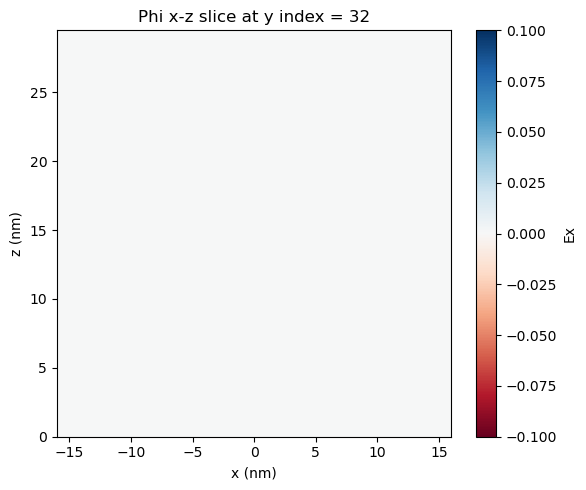

yt : [INFO     ] 2026-06-25 19:50:37,366 Parameters: current_time              = 4.844000000000124e-10
yt : [INFO     ] 2026-06-25 19:50:37,366 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,366 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,366 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


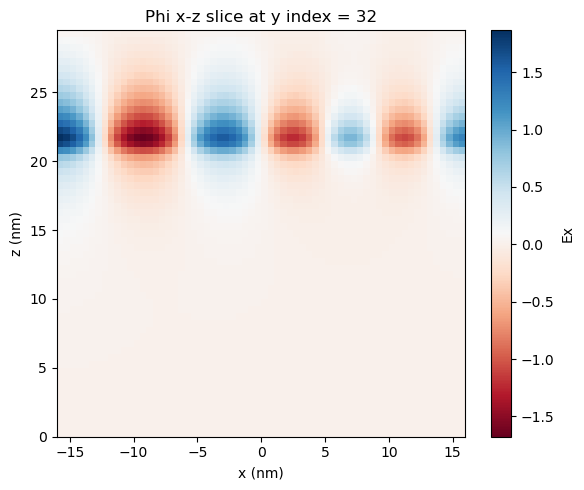

yt : [INFO     ] 2026-06-25 19:50:37,458 Parameters: current_time              = 7.28999999999961e-10
yt : [INFO     ] 2026-06-25 19:50:37,459 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,459 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,459 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


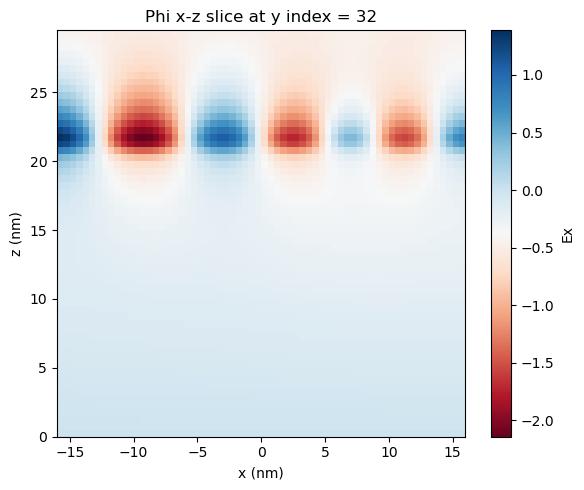

yt : [INFO     ] 2026-06-25 19:50:37,661 Parameters: current_time              = 9.547999999999256e-10
yt : [INFO     ] 2026-06-25 19:50:37,661 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,661 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,661 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


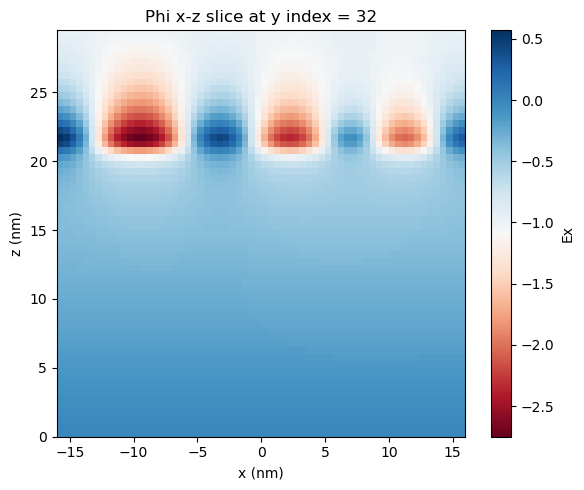

yt : [INFO     ] 2026-06-25 19:50:37,754 Parameters: current_time              = 1.376600000000055e-09
yt : [INFO     ] 2026-06-25 19:50:37,755 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,755 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,755 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


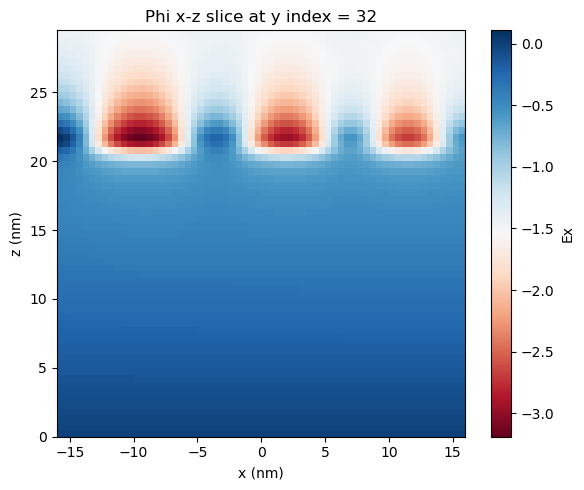

yt : [INFO     ] 2026-06-25 19:50:37,849 Parameters: current_time              = 1.918400000000221e-09
yt : [INFO     ] 2026-06-25 19:50:37,849 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,849 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,849 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


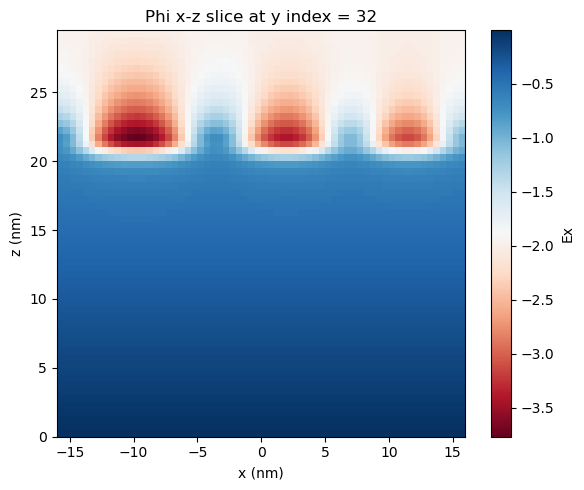

yt : [INFO     ] 2026-06-25 19:50:37,943 Parameters: current_time              = 2.4924000000003972e-09
yt : [INFO     ] 2026-06-25 19:50:37,943 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:37,943 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:37,944 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


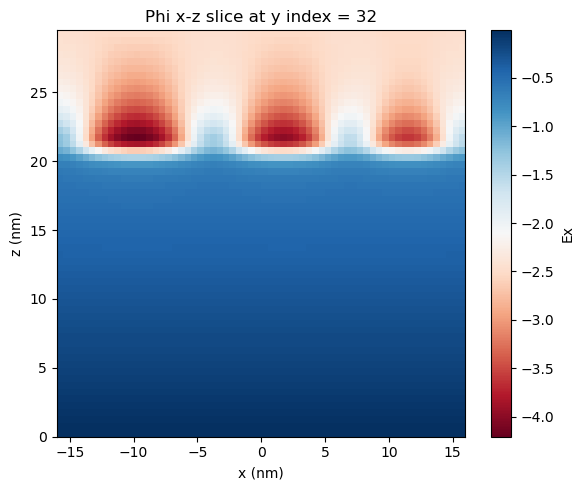

yt : [INFO     ] 2026-06-25 19:50:38,038 Parameters: current_time              = 2.898800000000522e-09
yt : [INFO     ] 2026-06-25 19:50:38,038 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,038 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,039 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


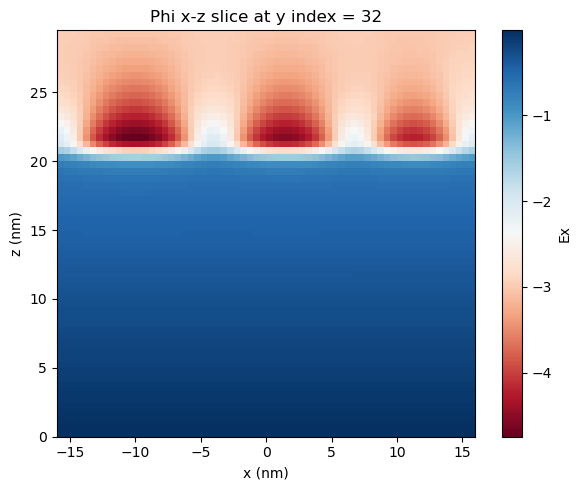

yt : [INFO     ] 2026-06-25 19:50:38,130 Parameters: current_time              = 3.1680000000006045e-09
yt : [INFO     ] 2026-06-25 19:50:38,130 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,130 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,130 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


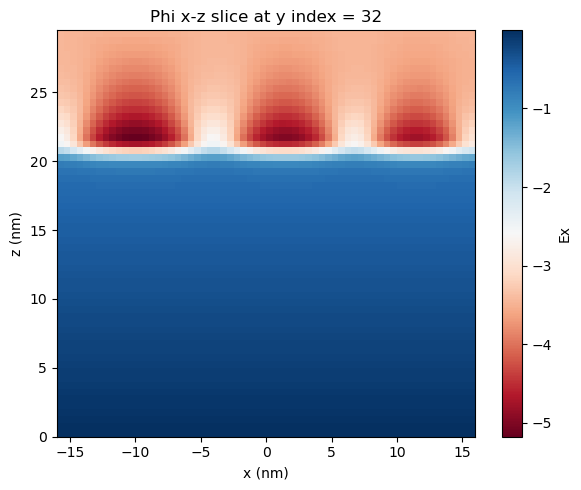

yt : [INFO     ] 2026-06-25 19:50:38,222 Parameters: current_time              = 3.6410000000007496e-09
yt : [INFO     ] 2026-06-25 19:50:38,222 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,223 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,223 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


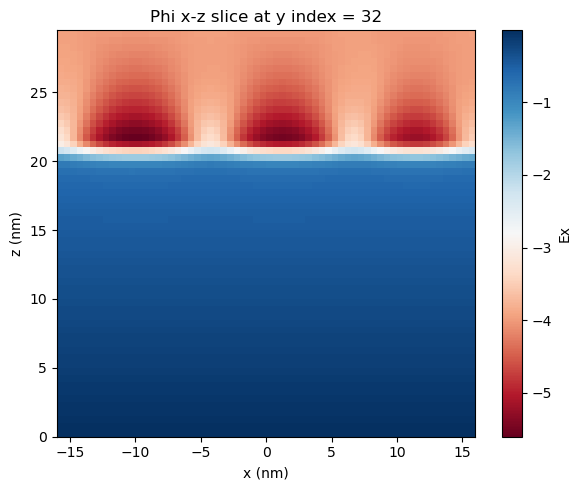

yt : [INFO     ] 2026-06-25 19:50:38,314 Parameters: current_time              = 4.018600000000865e-09
yt : [INFO     ] 2026-06-25 19:50:38,314 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,314 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,314 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


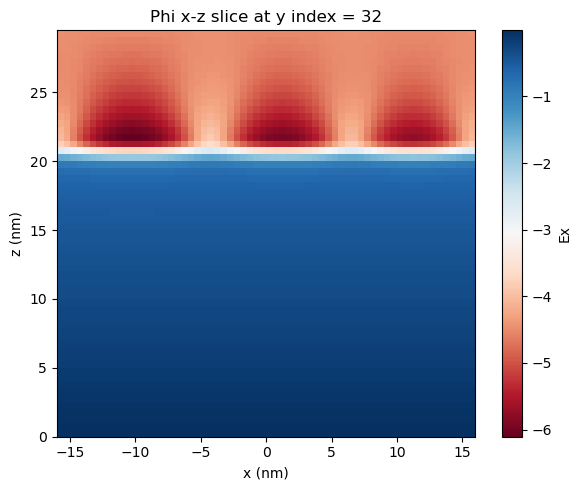

yt : [INFO     ] 2026-06-25 19:50:38,408 Parameters: current_time              = 4.591000000001041e-09
yt : [INFO     ] 2026-06-25 19:50:38,409 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,409 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,409 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


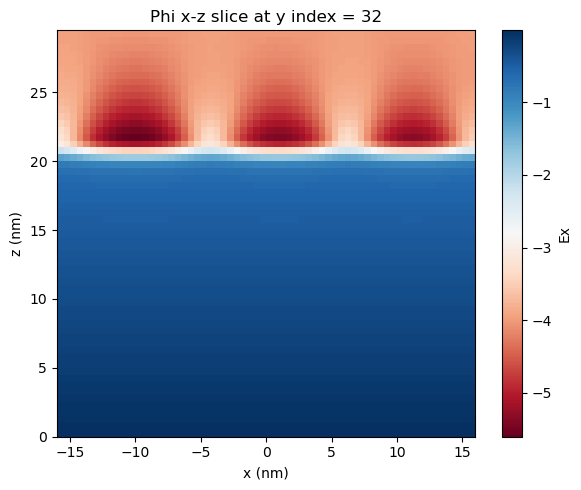

yt : [INFO     ] 2026-06-25 19:50:38,500 Parameters: current_time              = 5.263200000001247e-09
yt : [INFO     ] 2026-06-25 19:50:38,501 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,501 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,501 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


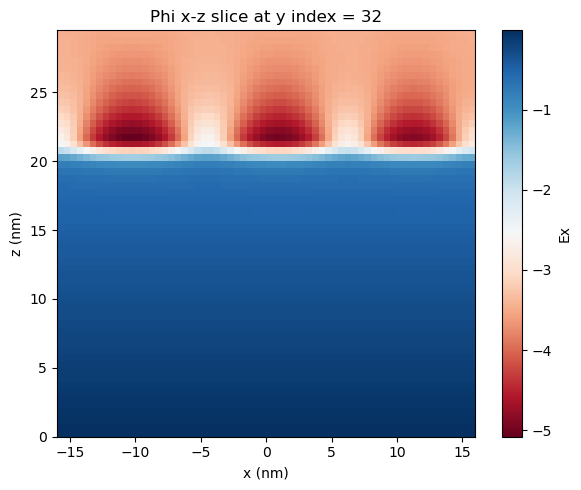

yt : [INFO     ] 2026-06-25 19:50:38,592 Parameters: current_time              = 5.538800000001332e-09
yt : [INFO     ] 2026-06-25 19:50:38,592 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,592 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,592 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


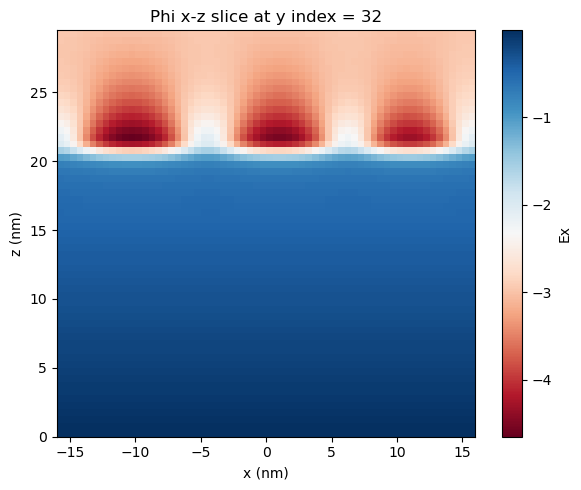

yt : [INFO     ] 2026-06-25 19:50:38,682 Parameters: current_time              = 6.0142000000014775e-09
yt : [INFO     ] 2026-06-25 19:50:38,682 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,683 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,683 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


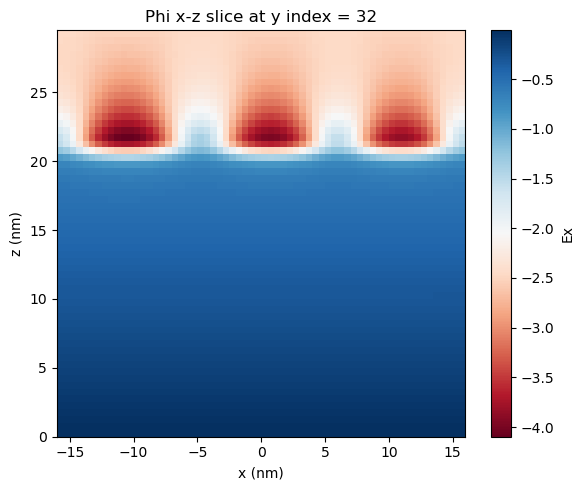

yt : [INFO     ] 2026-06-25 19:50:38,913 Parameters: current_time              = 6.31560000000157e-09
yt : [INFO     ] 2026-06-25 19:50:38,913 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:38,914 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:38,914 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


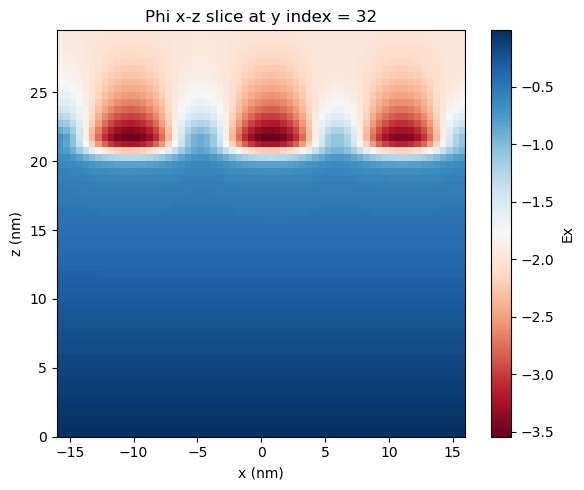

yt : [INFO     ] 2026-06-25 19:50:39,008 Parameters: current_time              = 6.688000000001684e-09
yt : [INFO     ] 2026-06-25 19:50:39,008 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,008 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,008 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


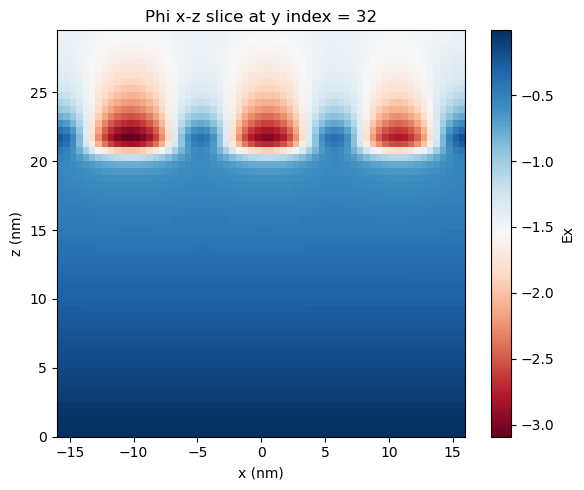

yt : [INFO     ] 2026-06-25 19:50:39,101 Parameters: current_time              = 6.938000000001761e-09
yt : [INFO     ] 2026-06-25 19:50:39,101 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,101 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,102 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


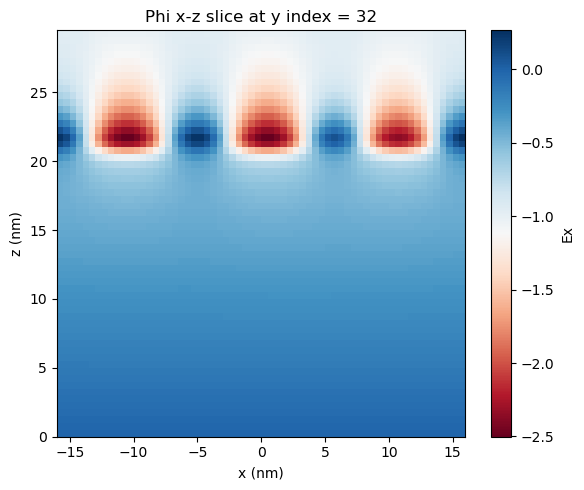

yt : [INFO     ] 2026-06-25 19:50:39,194 Parameters: current_time              = 7.113800000001815e-09
yt : [INFO     ] 2026-06-25 19:50:39,194 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,194 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,195 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


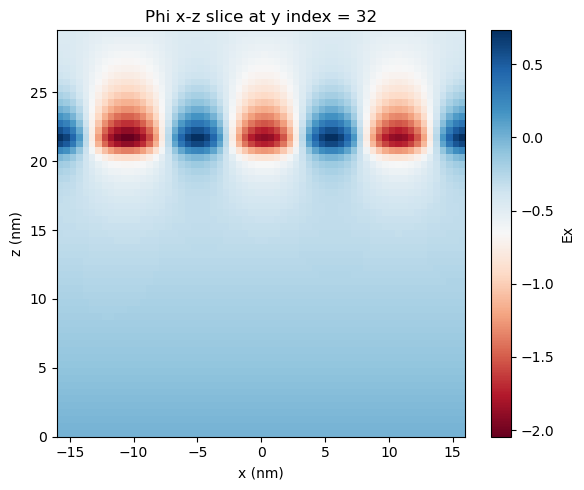

yt : [INFO     ] 2026-06-25 19:50:39,292 Parameters: current_time              = 7.4060000000019044e-09
yt : [INFO     ] 2026-06-25 19:50:39,292 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,292 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,292 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


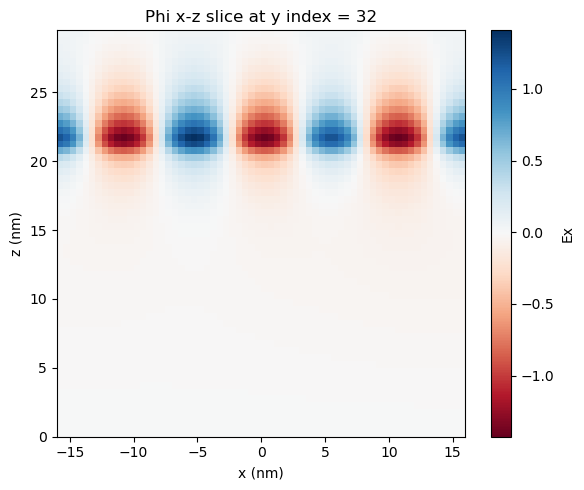

yt : [INFO     ] 2026-06-25 19:50:39,384 Parameters: current_time              = 7.503200000001716e-09
yt : [INFO     ] 2026-06-25 19:50:39,385 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,385 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,385 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


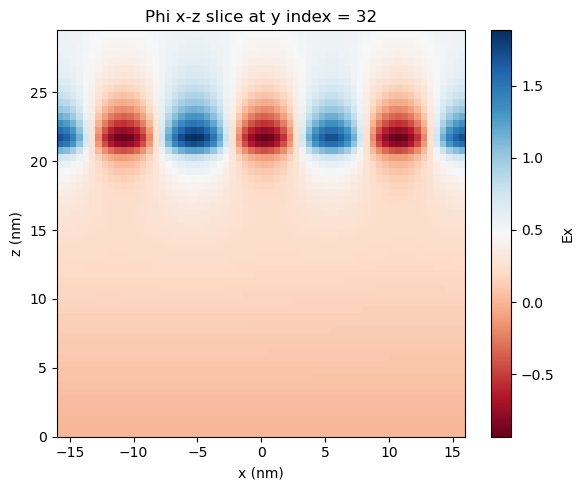

yt : [INFO     ] 2026-06-25 19:50:39,476 Parameters: current_time              = 7.777800000000664e-09
yt : [INFO     ] 2026-06-25 19:50:39,477 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,477 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,477 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


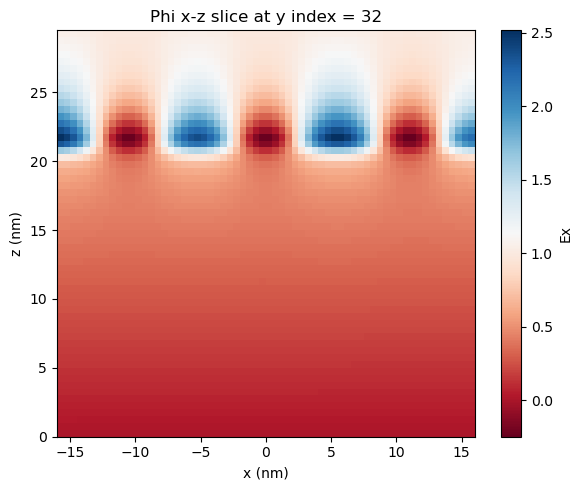

yt : [INFO     ] 2026-06-25 19:50:39,569 Parameters: current_time              = 8.032799999999688e-09
yt : [INFO     ] 2026-06-25 19:50:39,569 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,569 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,570 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


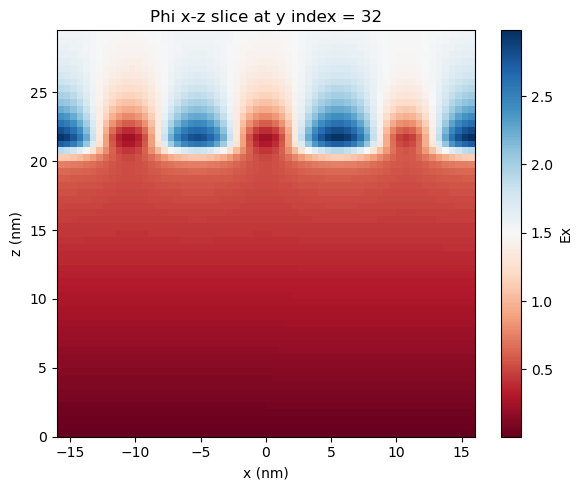

yt : [INFO     ] 2026-06-25 19:50:39,662 Parameters: current_time              = 8.278799999998746e-09
yt : [INFO     ] 2026-06-25 19:50:39,662 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,662 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,662 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


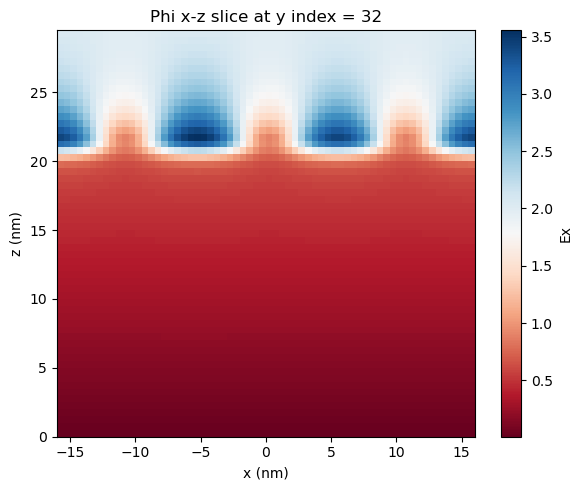

yt : [INFO     ] 2026-06-25 19:50:39,756 Parameters: current_time              = 1.0344199999990837e-08
yt : [INFO     ] 2026-06-25 19:50:39,756 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,757 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,757 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


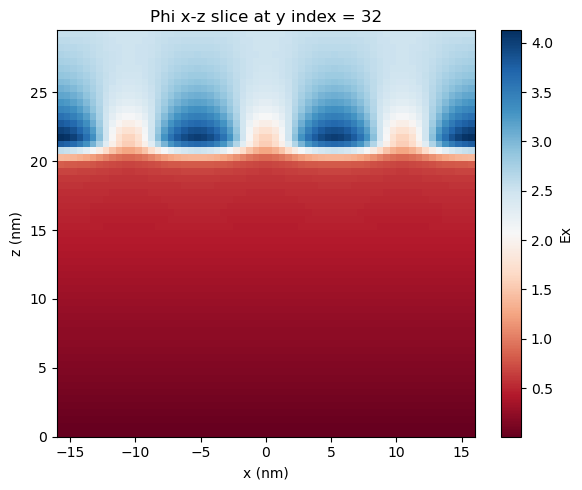

yt : [INFO     ] 2026-06-25 19:50:39,851 Parameters: current_time              = 1.0566399999989986e-08
yt : [INFO     ] 2026-06-25 19:50:39,852 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,852 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,852 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


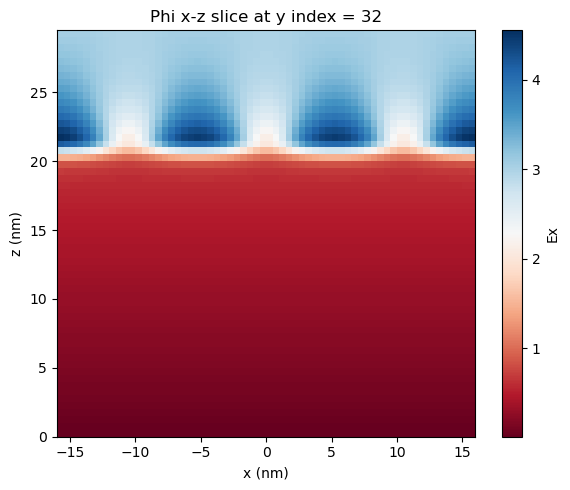

yt : [INFO     ] 2026-06-25 19:50:39,941 Parameters: current_time              = 1.1111599999987899e-08
yt : [INFO     ] 2026-06-25 19:50:39,941 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:39,942 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:39,942 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


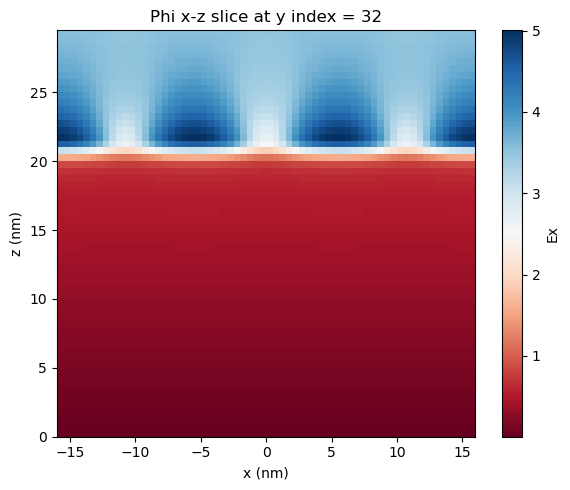

yt : [INFO     ] 2026-06-25 19:50:40,033 Parameters: current_time              = 1.1475399999986506e-08
yt : [INFO     ] 2026-06-25 19:50:40,033 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,034 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,034 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


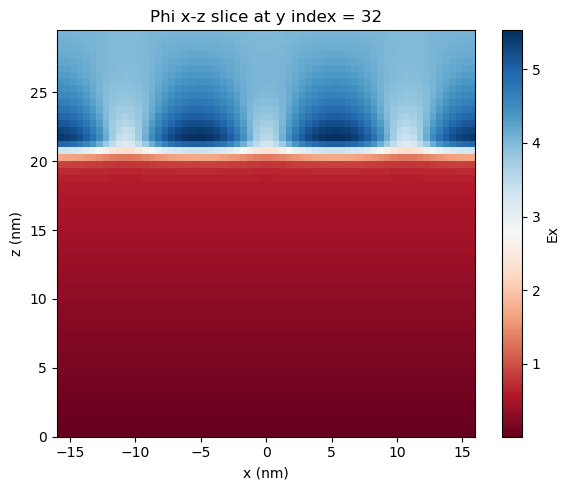

yt : [INFO     ] 2026-06-25 19:50:40,262 Parameters: current_time              = 1.2501799999982575e-08
yt : [INFO     ] 2026-06-25 19:50:40,262 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,262 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,262 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


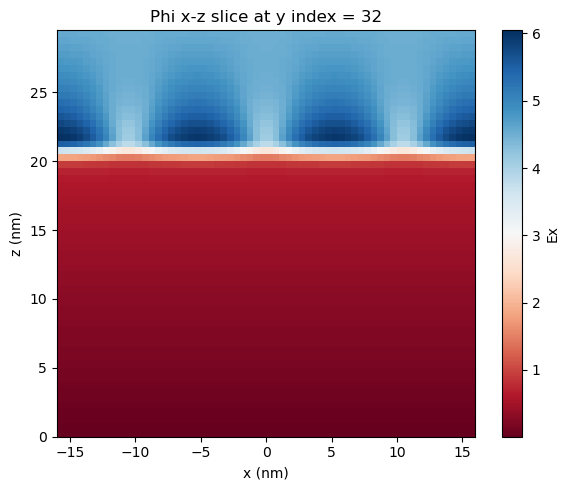

yt : [INFO     ] 2026-06-25 19:50:40,354 Parameters: current_time              = 1.290519999998103e-08
yt : [INFO     ] 2026-06-25 19:50:40,354 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,355 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,355 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


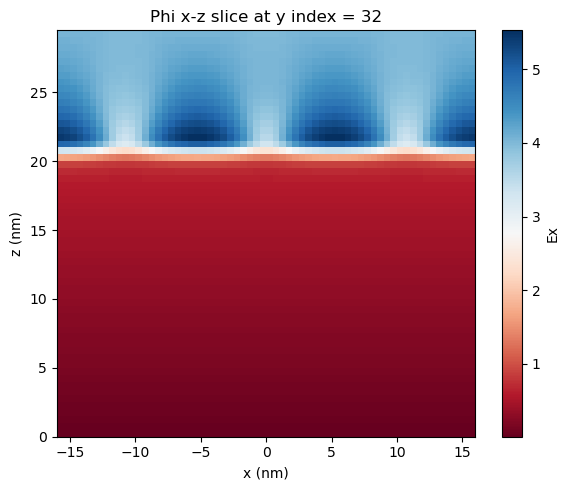

yt : [INFO     ] 2026-06-25 19:50:40,446 Parameters: current_time              = 1.3131399999980165e-08
yt : [INFO     ] 2026-06-25 19:50:40,446 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,447 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,447 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


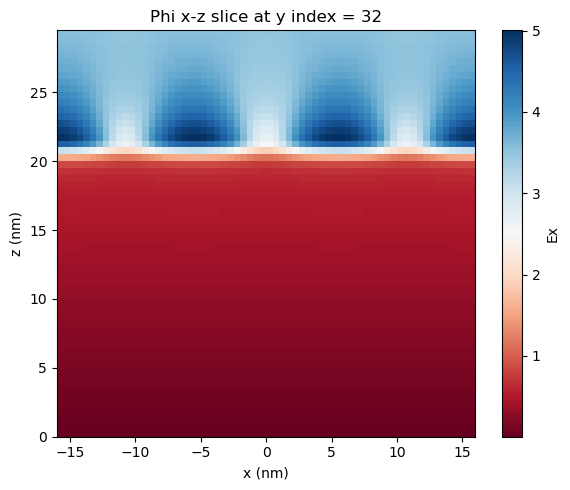

yt : [INFO     ] 2026-06-25 19:50:40,538 Parameters: current_time              = 1.3338199999979373e-08
yt : [INFO     ] 2026-06-25 19:50:40,538 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,539 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,539 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


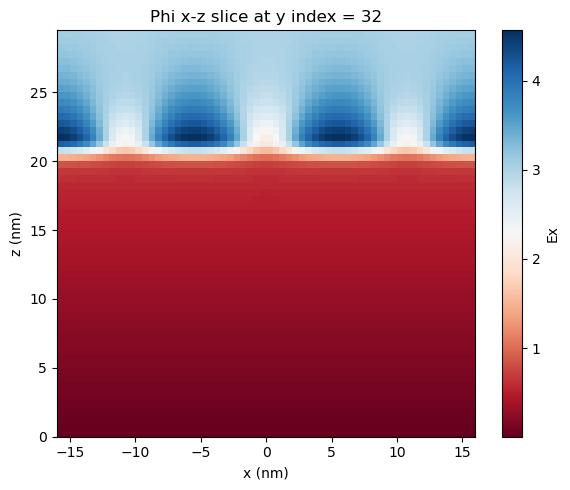

yt : [INFO     ] 2026-06-25 19:50:40,630 Parameters: current_time              = 1.5145799999974474e-08
yt : [INFO     ] 2026-06-25 19:50:40,630 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,630 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,630 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


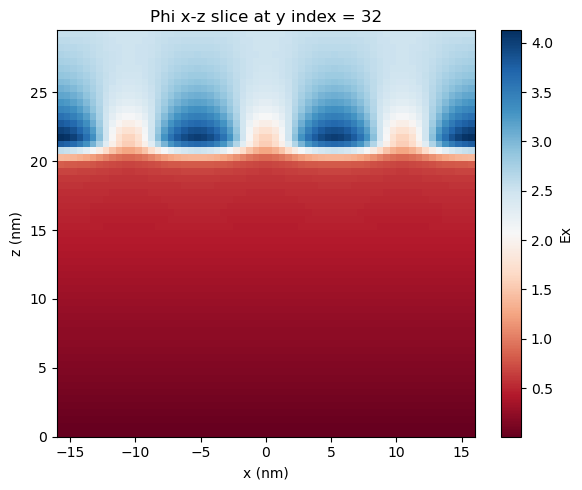

yt : [INFO     ] 2026-06-25 19:50:40,726 Parameters: current_time              = 1.5402199999975613e-08
yt : [INFO     ] 2026-06-25 19:50:40,726 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,726 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,726 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


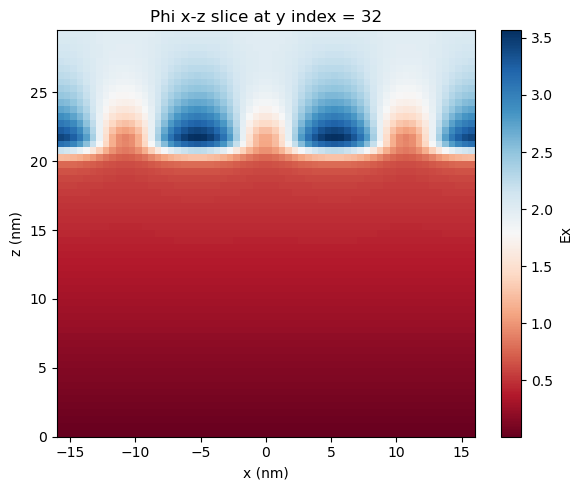

yt : [INFO     ] 2026-06-25 19:50:40,821 Parameters: current_time              = 1.5579999999976403e-08
yt : [INFO     ] 2026-06-25 19:50:40,821 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,821 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,822 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


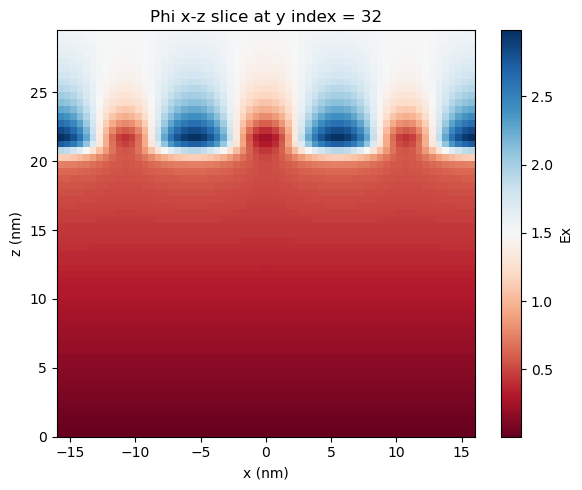

yt : [INFO     ] 2026-06-25 19:50:40,914 Parameters: current_time              = 1.572759999997706e-08
yt : [INFO     ] 2026-06-25 19:50:40,914 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:40,914 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:40,915 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


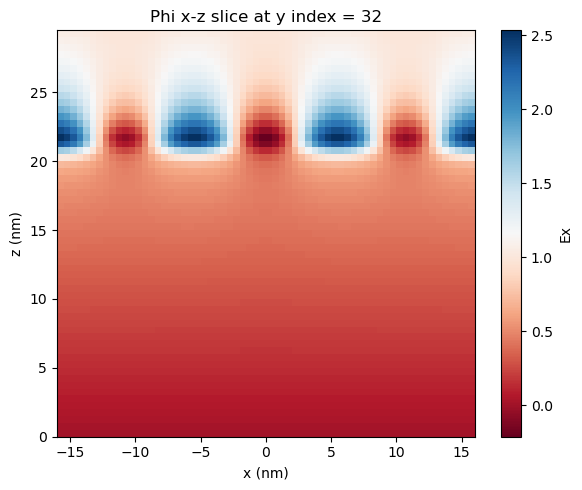

yt : [INFO     ] 2026-06-25 19:50:41,008 Parameters: current_time              = 1.5885999999977763e-08
yt : [INFO     ] 2026-06-25 19:50:41,008 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,008 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,008 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


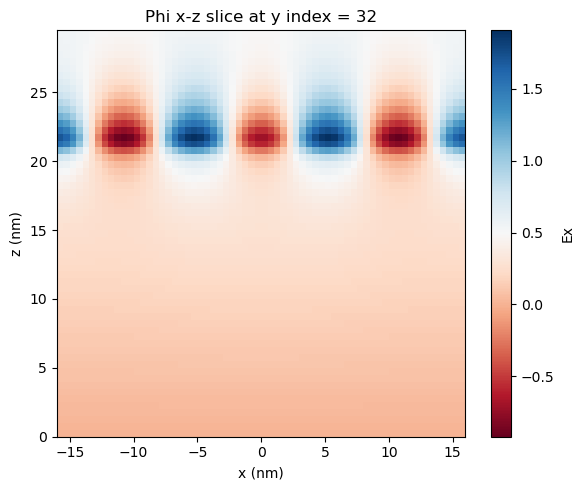

yt : [INFO     ] 2026-06-25 19:50:41,099 Parameters: current_time              = 1.5965599999978116e-08
yt : [INFO     ] 2026-06-25 19:50:41,100 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,100 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,100 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


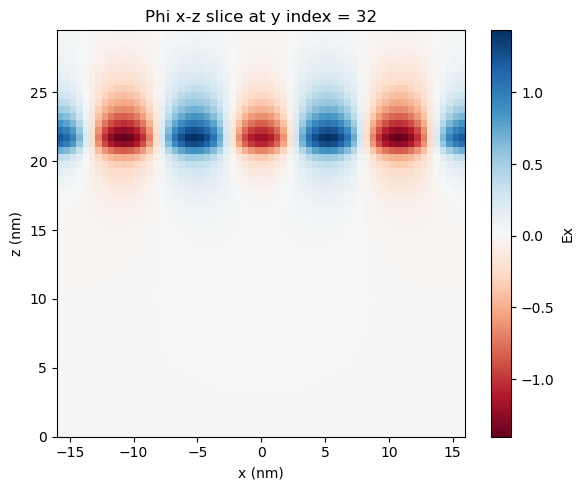

yt : [INFO     ] 2026-06-25 19:50:41,191 Parameters: current_time              = 1.605659999997852e-08
yt : [INFO     ] 2026-06-25 19:50:41,192 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,192 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,192 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


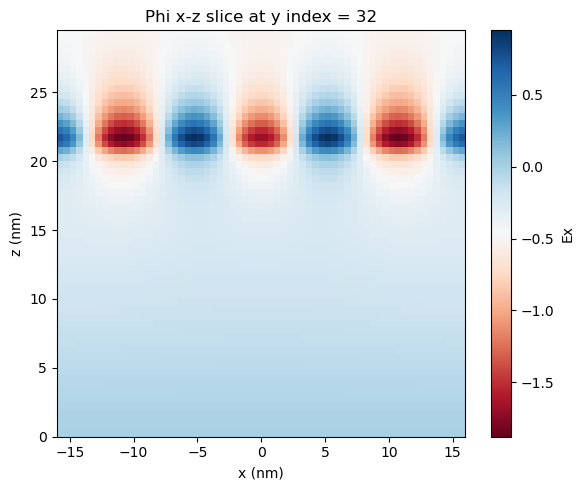

yt : [INFO     ] 2026-06-25 19:50:41,284 Parameters: current_time              = 1.6309799999979646e-08
yt : [INFO     ] 2026-06-25 19:50:41,284 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,284 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,285 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


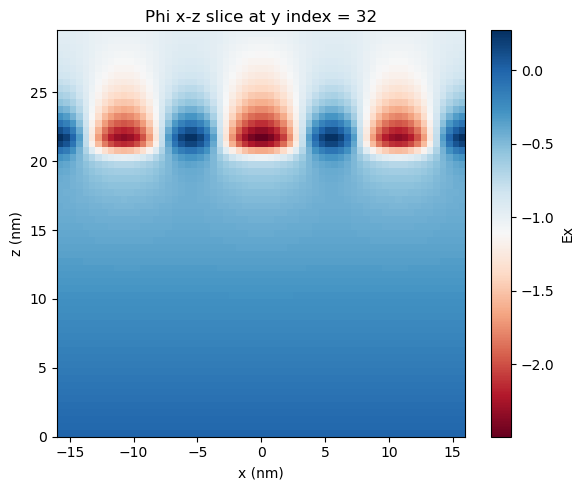

yt : [INFO     ] 2026-06-25 19:50:41,516 Parameters: current_time              = 1.645059999998027e-08
yt : [INFO     ] 2026-06-25 19:50:41,516 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,516 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,517 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


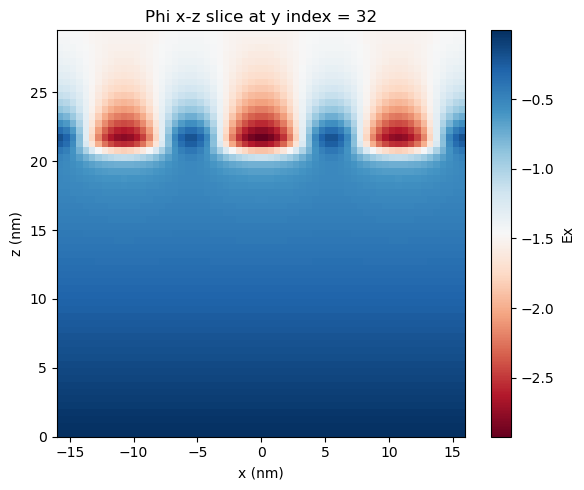

yt : [INFO     ] 2026-06-25 19:50:41,609 Parameters: current_time              = 1.7075599999983048e-08
yt : [INFO     ] 2026-06-25 19:50:41,609 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,609 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,609 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


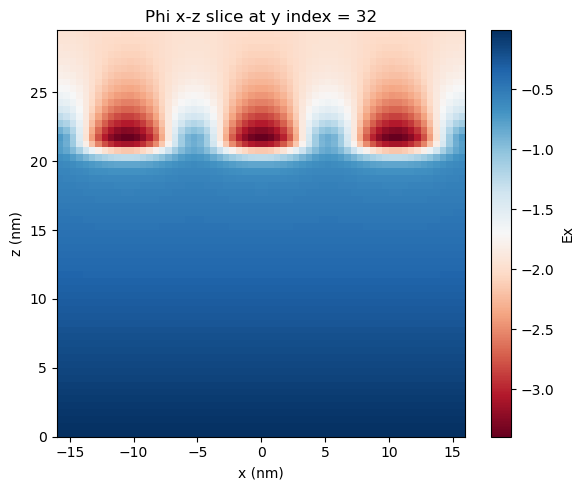

yt : [INFO     ] 2026-06-25 19:50:41,701 Parameters: current_time              = 1.7661999999985653e-08
yt : [INFO     ] 2026-06-25 19:50:41,701 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,701 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,701 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


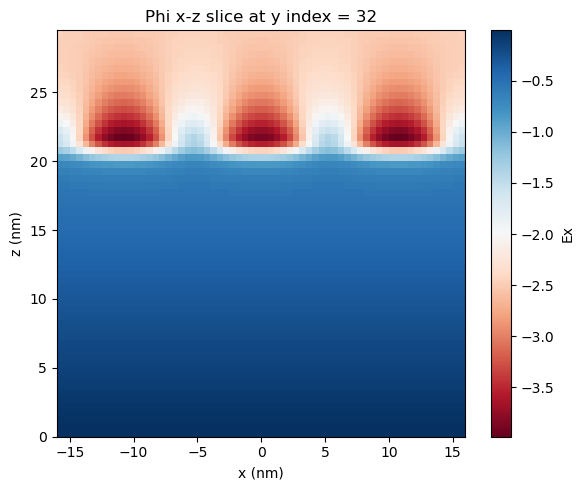

yt : [INFO     ] 2026-06-25 19:50:41,795 Parameters: current_time              = 1.7991399999987116e-08
yt : [INFO     ] 2026-06-25 19:50:41,795 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,795 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,796 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


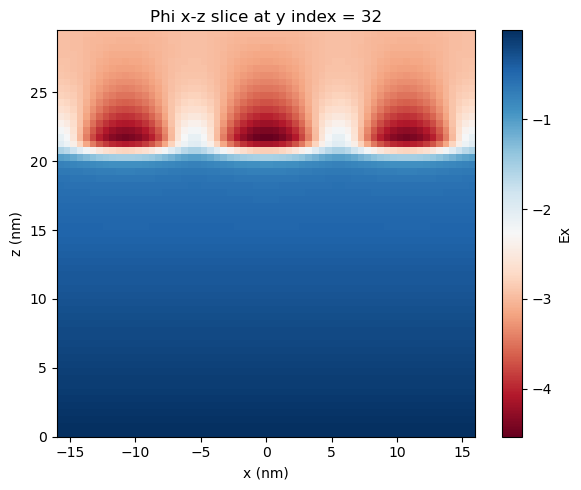

yt : [INFO     ] 2026-06-25 19:50:41,887 Parameters: current_time              = 2.172840000000372e-08
yt : [INFO     ] 2026-06-25 19:50:41,887 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,887 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,887 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


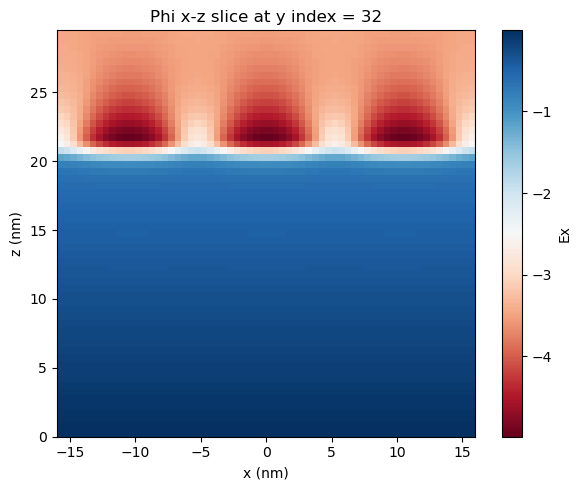

yt : [INFO     ] 2026-06-25 19:50:41,979 Parameters: current_time              = 2.2305600000006283e-08
yt : [INFO     ] 2026-06-25 19:50:41,980 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:41,980 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:41,980 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


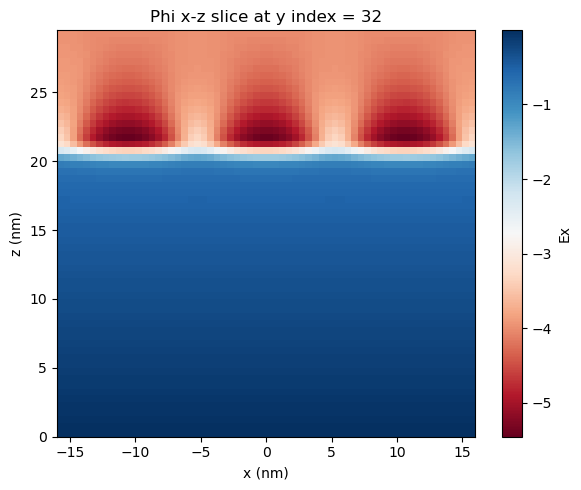

yt : [INFO     ] 2026-06-25 19:50:42,071 Parameters: current_time              = 2.2819000000008564e-08
yt : [INFO     ] 2026-06-25 19:50:42,072 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:42,072 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:42,072 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


Phi_array shape = (64, 64, 59)


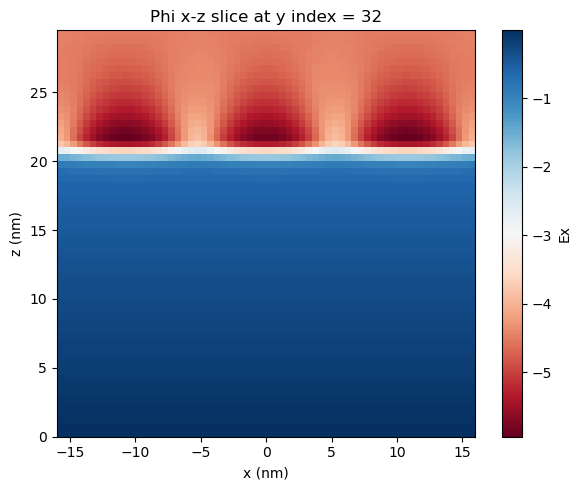

In [20]:
import yt
import numpy as np
import matplotlib.pyplot as plt
for i in range(len(plot_names)):
    plotfile = PLOT_DIR/plot_names[i] 
    field = ("boxlib", "Phi")

    ds = yt.load(plotfile)

    #g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
    Phi_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid

    print("Phi_array shape =", Phi_array.shape)

    Nx, Ny, Nz = Phi_array.shape #用index存資料

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dims = np.array([Nx, Ny, Nz])

    dx = (hi - lo) / dims

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    y0 = Ny // 2
    slice2d = Phi_array[:, y0, :]

    plt.figure(figsize=(6, 5))
    im = plt.pcolormesh(
        x_nm,
        z_nm,
        slice2d.T,
        shading="auto",
        cmap="RdBu"
    )

    plt.colorbar(im, label="Ex")
    plt.xlabel("x (nm)")
    plt.ylabel("z (nm)")
    plt.title(f"Phi x-z slice at y index = {y0}")
    plt.tight_layout()
    plt.show()

yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: current_time              = 7.28999999999961e-10
yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:50:42,168 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


E_array shape = (64, 64, 59)


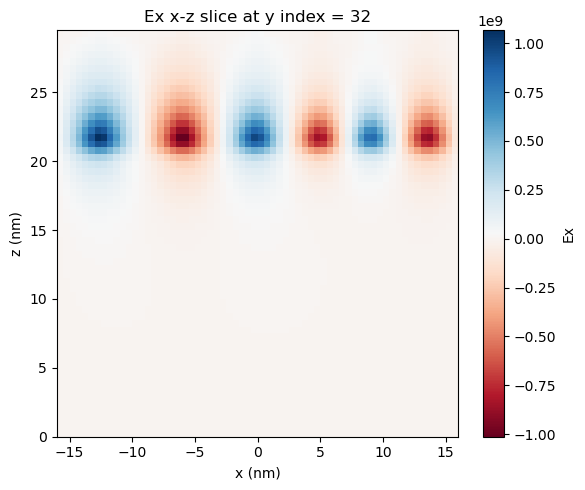

In [21]:
import yt
import numpy as np
import matplotlib.pyplot as plt

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_plt")  # 改成你 plotfile 所在的資料夾
plotfile = PLOT_DIR/plot_names[2] 
field = ("boxlib", "Ex")

ds = yt.load(plotfile)

#g = ds.index.grids[0] # 先看 grid 0，多個 grid 的話要自己想辦法合併資料
E_array = read_full_field_from_grids(ds, field) # 讀取整個 domain 的 Ex 資料，會自動合併多個 grid

print("E_array shape =", E_array.shape)

Nx, Ny, Nz = E_array.shape #用index存資料

lo = ds.domain_left_edge.to_value()
hi = ds.domain_right_edge.to_value()
dims = np.array([Nx, Ny, Nz])

dx = (hi - lo) / dims

x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9 #index對應空間位置
z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

y0 = Ny // 2
slice2d = E_array[:, y0, :]

plt.figure(figsize=(6, 5))
im = plt.pcolormesh(
    x_nm,
    z_nm,
    slice2d.T,
    shading="auto",
    cmap="RdBu"
)

plt.colorbar(im, label="Ex")
plt.xlabel("x (nm)")
plt.ylabel("z (nm)")
plt.title(f"Ex x-z slice at y index = {y0}")
plt.tight_layout()
plt.show()

## 2D Pz slice plot(all voltage in same graph)

yt : [INFO     ] 2026-06-25 19:51:04,343 Parameters: current_time              = 4.018600000000865e-09
yt : [INFO     ] 2026-06-25 19:51:04,343 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:51:04,343 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:51:04,343 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]


yt : [INFO     ] 2026-06-25 19:51:04,386 Parameters: current_time              = 4.591000000001041e-09
yt : [INFO     ] 2026-06-25 19:51:04,386 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:51:04,387 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:51:04,387 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-25 19:51:04,427 Parameters: current_time              = 5.263200000001247e-09
yt : [INFO     ] 2026-06-25 19:51:04,427 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:51:04,428 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:51:04,428 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-25 19:51:04,469 Parameters: current_time              = 5.538800000001332e-09
yt : [INFO     ] 2026-06-25 19:51:04,469 Parameters: domain_dimensi

Plotfiles to draw:
  plt00020093
  plt00022955
  plt00026316
  plt00027694
  plt00030071
  plt00031578
  plt00033440
  plt00034690
  plt00035569
  plt00037030
  plt00037516
  plt00038889
  plt00040164
  plt00041394
  plt00051721
  plt00052832
  plt00055558
  plt00057377
  plt00062509
  plt00064526
  plt00065657
  plt00066691
  plt00075729
  plt00077011
  plt00077900
  plt00078638
  plt00079430
  plt00079828
  plt00080283
  plt00081549
  plt00082253
  plt00085378
  plt00088310
  plt00089957
  plt00108642
  plt00111528
  plt00114095
37 number of plotfiles will be drawn after filtering.


yt : [INFO     ] 2026-06-25 19:51:04,552 Parameters: current_time              = 6.31560000000157e-09
yt : [INFO     ] 2026-06-25 19:51:04,552 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:51:04,553 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:51:04,553 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-25 19:51:04,724 Parameters: current_time              = 6.688000000001684e-09
yt : [INFO     ] 2026-06-25 19:51:04,724 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 19:51:04,725 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 19:51:04,725 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.95e-08]
yt : [INFO     ] 2026-06-25 19:51:04,765 Parameters: current_time              = 6.938000000001761e-09
yt : [INFO     ] 2026-06-25 19:51:04,766 Parameters: domain_dimensio

Drawing 2 plots after filtering.


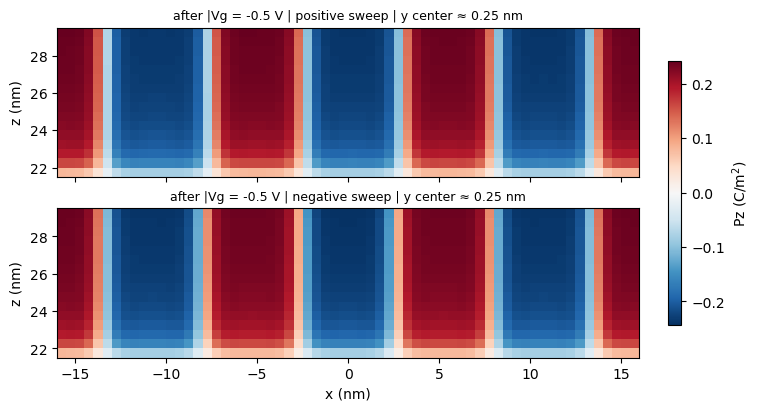

In [22]:
from pathlib import Path
import re

import yt
import numpy as np
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec")          # plotfile 所在資料夾
P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")

# ==========================
# Selection list (NEW)
# ==========================
# format: (voltage, direction)
# voltage 用 None 表示 wildcard
# direction 用 None 表示 wildcard

SELECT_LIST = [
    
    (-0.5, "positive sweep"), 
    (-0.5, "negative sweep"),
   
]

#SELECT_LIST = None  # 不過濾，全部畫出來
USE_FE_X_RANGE = False

# y slice: None 表示取 y 方向正中間
Y_INDEX = None

# 若 plot_names 已經是你前面整理好的 steady-state plot list，就直接用
# plot_names = [...]
# 若沒有，就自動抓目前資料夾內所有 plt########
AUTO_FIND_PLOTS = False

# 跳過 initial plt00000000
SKIP_INITIAL = True

# 色階是否對稱於 0，畫 Pz 通常建議 True
SYMMETRIC_COLOR_SCALE = False

# 輸出圖片名稱
SAVE_FIG = False
OUT_FIG = PLOT_DIR/"Pz_FE_layer_stack.png"


# ==========================
# Helper functions
# ==========================


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v


def read_one_plot(plotfile, y_index=None):
    ds = yt.load(str(plotfile))
    #g = ds.index.grids[0]

    P = read_full_field_from_grids(ds, P_FIELD) # 讀取整個 domain 的 Pz 資料，會自動合併多個 grid
    P*=-1
    if PHI_FIELD in ds.field_list:
        Phi = read_full_field_from_grids(ds, PHI_FIELD) # 讀取整個 domain 的 Phi 資料，會自動合併多個 grid
    else:
        Phi = None

    Nx, Ny, Nz = P.shape

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    if y_index is None:
        y_index = Ny // 2

    # FE z range mask
    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    # P slice: shape after selection = (Nx_sel, Nz_sel)
    P_slice = P[np.ix_(x_sel, [y_index], z_sel)][:, 0, :]

    x_plot = x_nm[x_sel]
    z_plot = z_nm[z_sel]

    # 用最上層 cell 的 Phi 平均值當 top potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    if Phi is not None:
        top_phi = Phi[:, :, -1]
        Vtop_mean = float(np.mean(top_phi))
        Vtop_min = float(np.min(top_phi))
        Vtop_max = float(np.max(top_phi))
    else:
        Vtop_mean = np.nan
        Vtop_min = np.nan
        Vtop_max = np.nan

    info = {
        "ds": ds,
        "P_slice": P_slice,
        "x_nm": x_plot,
        "z_nm": z_plot,
        "y_index": y_index,
        "y_nm": float(y_nm[y_index]),
        "Vtop_mean": Vtop_mean,
        "Vtop_min": Vtop_min,
        "Vtop_max": Vtop_max,
        "shape": P.shape,
    }

    return info



def match(rec, direction):# FILTER BY SELECT_LIST
    if not SELECT_LIST:
        return True
    V = rec["Vtop_mean"]

    for v_target, d_target in SELECT_LIST:

        ok_v = (v_target is None) or (
            np.isfinite(V) and np.isclose(V, v_target, atol=1e-1)
        )

        ok_d = (d_target is None) or (direction == d_target)

        if ok_v and ok_d:
            return True

    return False

# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

# sort by step if names are plt########
plot_names_use = sorted(plot_names_use, key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]

#忽略第一段
plot_names_use = plot_names_use[9:]
    
print("Plotfiles to draw:")
for n in plot_names_use:
    print(" ", n)
print(len(plot_names_use), "number of plotfiles will be drawn after filtering.")

records = []
all_values = []

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    info = read_one_plot(plotfile, y_index=Y_INDEX)

    step = get_step_from_name(name)

    records.append({
        "name": name,
        "step": step,
        **info,
    })

    all_values.append(info["P_slice"])

# shared color scale
all_concat = np.concatenate([v.ravel() for v in all_values])
if SYMMETRIC_COLOR_SCALE:
    vmax = np.nanmax(np.abs(all_concat))
    vmin = -vmax
else:
    vmin = np.nanmin(all_concat)
    vmax = np.nanmax(all_concat)

# determine sweep direction from Vtop sequence
Vseq = np.array([r["Vtop_mean"] for r in records], dtype=float)

directions = []
for idx, V in enumerate(Vseq):
    if idx == 0 or not np.isfinite(Vseq[idx-1]) or not np.isfinite(V):
        directions.append("start")
    else:
        dV = V - Vseq[idx-1]
        if dV > 1e-8:
            directions.append("positive sweep")
        elif dV < -1e-8:
            directions.append("negative sweep")
        else:
            directions.append("same V")

filtered_records = []
filtered_directions = []

for rec, d in zip(records, directions):
    if match(rec, d):
        filtered_records.append(rec)
        filtered_directions.append(d)

records = filtered_records
directions = filtered_directions

# figure size
n = len(records)
print(f"Drawing {n} plots after filtering.")
fig_height = max(2.0 * n, 4.0)
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(7.5, fig_height),
    sharex=True,
    constrained_layout=True
)


if n == 1:
    axes = [axes]

last_im = None

for ax, rec, sweep_dir in zip(axes, records, directions):
    P_slice = rec["P_slice"]
    x_nm = rec["x_nm"]
    z_nm = rec["z_nm"]

    last_im = ax.pcolormesh(
        x_nm,
        z_nm,
        P_slice.T,
        shading="auto",
        cmap="RdBu_r",
        vmin=vmin,
        vmax=vmax
    )

    Vmean = rec["Vtop_mean"]
    Vmin = rec["Vtop_min"]
    Vmax = rec["Vtop_max"]

    if np.isfinite(Vmean):
        v_label = f"Vg = {Vmean:+.1f} V"
        # 若你想檢查 top x/y variation，也可以顯示 min/max
        # v_label += f" [{Vmin:+.3f}, {Vmax:+.3f}]"
    else:
        v_label = "Vtop unavailable"

    step_label = f"step={rec['step']}" if rec["step"] is not None else rec["name"]

    ax.set_ylabel("z (nm)")

    ax.set_title(
        f"after |"
        f"{v_label} | {sweep_dir} | "
        f"y center ≈ {rec['y_nm']:.2f} nm",
        fontsize=9
    )

axes[-1].set_xlabel("x (nm)")
axes[-1].tick_params(axis='x', labelbottom=True)
'''
for ax in axes:
    ax.set_xlabel("x (nm)")
    ax.tick_params(axis='x', labelbottom=True)
'''
cbar = fig.colorbar(last_im, ax=axes, shrink=0.8)
cbar.set_label(r"Pz (C/m$^2$)")

if SAVE_FIG:
    fig.savefig(OUT_FIG, dpi=200)
    print(f"Saved figure: {OUT_FIG}")

plt.show()

## PV

### User Settings

In [29]:
from pathlib import Path
import re

import yt
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# ==========================
# User settings
# ==========================

#PLOT_DIR = Path("/home/kaiwi/FAM/FerroX/Exec/MFIS_t_8_1_plt")

P_FIELD = ("boxlib", "Pz")
PHI_FIELD = ("boxlib", "Phi")


# 如果 FE 是全幅 MFIS，通常不用限制 x/y
USE_FE_X_RANGE = False


USE_FE_Y_RANGE = False
# 若你已經有 steady-state plot_names，就用 AUTO_FIND_PLOTS=False
# plot_names = [...]
AUTO_FIND_PLOTS = True

# 如果沒有 plot_names，可以自動找所有 plt########
# 但建議最好只用 steady-state plotfiles
SKIP_INITIAL = True

OUT_CSV = "./figs/MFIS_PV_curve.csv"
OUT_FIG = "./figs/MFIS_PV_curve.png"


### Utils

In [30]:
# ==========================
# Helper functions
# ==========================

def get_step_from_name(name):
    m = re.fullmatch(r"plt(\d+)", str(name))
    return int(m.group(1)) if m else None


def find_plot_names(plot_dir):
    names = []
    for p in plot_dir.iterdir():
        if p.is_dir() and re.fullmatch(r"plt\d+", p.name):
            names.append(p.name)
    names.sort(key=lambda n: get_step_from_name(n))
    return names


def to_numpy(field_data):
    try:
        return field_data.to_ndarray()
    except AttributeError:
        return field_data.v

def read_full_field_from_grids(ds, field):
    """
    Read a cell-centered AMReX field from all yt grids
    and stitch them into one full-domain numpy array.

    Return:
        full: numpy array with shape ds.domain_dimensions
    """
    dims = np.array(ds.domain_dimensions, dtype=int)
    full = np.empty(tuple(dims), dtype=float)

    domain_lo = ds.domain_left_edge.to_value()
    domain_hi = ds.domain_right_edge.to_value()
    dx = (domain_hi - domain_lo) / dims

    for grid in ds.index.grids:
        arr = to_numpy(grid[field])

        left = grid.LeftEdge.to_value()

        # grid start index in global domain
        start = np.rint((left - domain_lo) / dx).astype(int)

        nx, ny, nz = arr.shape
        i0, j0, k0 = start
        i1, j1, k1 = i0 + nx, j0 + ny, k0 + nz

        full[i0:i1, j0:j1, k0:k1] = arr

    return full

def read_pv_from_plot(plotfile):
    ds = yt.load(str(plotfile))
    Pz = read_full_field_from_grids(ds, P_FIELD)
    Phi = read_full_field_from_grids(ds, PHI_FIELD)

    Nx, Ny, Nz = Pz.shape
    print(f"Read Pz with shape {Pz.shape} from {plotfile}")

    lo = ds.domain_left_edge.to_value()
    hi = ds.domain_right_edge.to_value()
    print(f"Domain: x [{lo[0]:.3e}, {hi[0]:.3e}] m, "
          f"y [{lo[1]:.3e}, {hi[1]:.3e}] m, "
          f"z [{lo[2]:.3e}, {hi[2]:.3e}] m")
    dx = (hi - lo) / np.array([Nx, Ny, Nz])

    x_nm = (lo[0] + (np.arange(Nx) + 0.5) * dx[0]) * 1e9
    y_nm = (lo[1] + (np.arange(Ny) + 0.5) * dx[1]) * 1e9
    z_nm = (lo[2] + (np.arange(Nz) + 0.5) * dx[2]) * 1e9

    z_sel = (z_nm >= FE_Z_LO_NM) & (z_nm <= FE_Z_HI_NM)

    if USE_FE_X_RANGE:
        x_sel = (x_nm >= FE_X_LO_NM) & (x_nm <= FE_X_HI_NM)
    else:
        x_sel = np.ones_like(x_nm, dtype=bool)

    if USE_FE_Y_RANGE:
        y_sel = (y_nm >= FE_Y_LO_NM) & (y_nm <= FE_Y_HI_NM)
    else:
        y_sel = np.ones_like(y_nm, dtype=bool)

    Pz_FE = Pz[np.ix_(x_sel, y_sel, z_sel)]

    P_mean = float(np.mean(Pz_FE))
    P_min = float(np.min(Pz_FE))
    P_max = float(np.max(Pz_FE))
    P_std = float(np.std(Pz_FE))

    # 用最上層 cell 的 Phi 平均值估 top electrode potential
    # 注意：這是 top cell center，不是真正 ghost boundary
    top_phi = Phi[:, :, -1]
    Vg_mean = float(np.mean(top_phi))
    Vg_min = float(np.min(top_phi))
    Vg_max = float(np.max(top_phi))
    Vg_std = float(np.std(top_phi))

    return {
        "P_mean": P_mean,
        "P_min": P_min,
        "P_max": P_max,
        "P_std": P_std,
        "Vg_mean": Vg_mean,
        "Vg_min": Vg_min,
        "Vg_max": Vg_max,
        "Vg_std": Vg_std,
        "Nx": Nx,
        "Ny": Ny,
        "Nz": Nz,
        "num_FE_cells": int(Pz_FE.size),
    }



### Data Preparation

In [31]:



# ==========================
# Main
# ==========================

if AUTO_FIND_PLOTS:
    print(f"Finding plotfiles in {PLOT_DIR}...")
    plot_names_use = find_plot_names(PLOT_DIR)
else:
    plot_names_use = list(plot_names)

plot_names_use = sorted(
    plot_names_use,
    key=lambda n: get_step_from_name(n) if get_step_from_name(n) is not None else 10**99
)

if SKIP_INITIAL:
    plot_names_use = [
        n for n in plot_names_use
        if get_step_from_name(n) != 0
    ]
plot_names_use = plot_names_use[9:]  # skip first 9 plotfiles
rows = []

print(plot_names_use)

for name in plot_names_use:
    plotfile = PLOT_DIR / name
    step = get_step_from_name(name)

    info = read_pv_from_plot(plotfile)

    rows.append({
        "plotfile": name,
        "step": step,
        **info,
    })

    print(
        f"{name} | step={step} | "
        f"Vg={info['Vg_mean']:+.4f} V | "
        f"<Pz>_FE={info['P_mean']:+.6e}"
    )

df = pd.DataFrame(rows)
df.to_csv(OUT_CSV, index=False)
print(f"Saved CSV: {OUT_CSV}")


# ==========================
# Determine sweep direction
# ==========================

V = df["Vg_mean"].to_numpy()
P = df["P_mean"].to_numpy()


direction = np.zeros_like(V)

for i in range(1, len(V)):
    dV = V[i] - V[i - 1]
    if dV > 1e-8:
        direction[i] = 1   # positive sweep
    elif dV < -1e-8:
        direction[i] = -1  # negative sweep
    else:
        direction[i] = direction[i - 1]

#np.append(direction, direction[-1])  # 複製第一筆到最後

df["sweep_direction"] = direction
df.to_csv(OUT_CSV, index=False)




yt : [INFO     ] 2026-06-25 22:46:26,016 Parameters: current_time              = 4.396400000000981e-09
yt : [INFO     ] 2026-06-25 22:46:26,016 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:26,016 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:26,017 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:26,058 Parameters: current_time              = 4.610800000001047e-09
yt : [INFO     ] 2026-06-25 22:46:26,058 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:26,058 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:26,058 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:26,100 Parameters: current_time              = 4.932200000001146e-09
yt : [INFO     ] 2026-06-25 22:46:26,100 Parameters: domain_dimensi

Finding plotfiles in plts...
['plt00021982', 'plt00023054', 'plt00024661', 'plt00025172', 'plt00026485', 'plt00027919', 'plt00028357', 'plt00029575', 'plt00030520', 'plt00031624', 'plt00032099', 'plt00033475', 'plt00033987', 'plt00035551', 'plt00036822', 'plt00038532', 'plt00039455', 'plt00043354', 'plt00044579', 'plt00045356', 'plt00047924', 'plt00049357', 'plt00051046', 'plt00052367', 'plt00052814', 'plt00054183', 'plt00055026', 'plt00056173', 'plt00056634', 'plt00058453', 'plt00058931', 'plt00060644', 'plt00062022', 'plt00064293', 'plt00065100', 'plt00068009', 'plt00069499']
Read Pz with shape (64, 64, 59) from plts/plt00021982
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00021982 | step=21982 | Vg=-4.5033 V | <Pz>_FE=+8.179414e-02
Read Pz with shape (64, 64, 59) from plts/plt00023054
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00023054 | step=23054 | Vg=-4.0020 V | <Pz>_FE=+7.2757

yt : [INFO     ] 2026-06-25 22:46:26,224 Parameters: current_time              = 5.5838000000013455e-09
yt : [INFO     ] 2026-06-25 22:46:26,224 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:26,224 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:26,225 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:26,266 Parameters: current_time              = 5.671400000001372e-09
yt : [INFO     ] 2026-06-25 22:46:26,266 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:26,266 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:26,267 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:26,307 Parameters: current_time              = 5.915000000001447e-09
yt : [INFO     ] 2026-06-25 22:46:26,307 Parameters: domain_dimens

Read Pz with shape (64, 64, 59) from plts/plt00026485
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00026485 | step=26485 | Vg=-2.4978 V | <Pz>_FE=+4.460836e-02
Read Pz with shape (64, 64, 59) from plts/plt00027919
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00027919 | step=27919 | Vg=-1.9918 V | <Pz>_FE=+2.986099e-02
Read Pz with shape (64, 64, 59) from plts/plt00028357
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00028357 | step=28357 | Vg=-1.4928 V | <Pz>_FE=+2.363539e-02
Read Pz with shape (64, 64, 59) from plts/plt00029575
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00029575 | step=29575 | Vg=-0.9888 V | <Pz>_FE=+1.200239e-02
Read Pz with shape (64, 64, 59) from plts/plt00030520
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt000305

yt : [INFO     ] 2026-06-25 22:46:26,431 Parameters: current_time              = 6.419800000001602e-09
yt : [INFO     ] 2026-06-25 22:46:26,431 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:26,431 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:26,431 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:26,582 Parameters: current_time              = 6.695000000001686e-09
yt : [INFO     ] 2026-06-25 22:46:26,582 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:26,582 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:26,582 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


...

Read Pz with shape (64, 64, 59) from plts/plt00056173
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00056173 | step=56173 | Vg=+0.0155 V | <Pz>_FE=-4.657194e-05
Read Pz with shape (64, 64, 59) from plts/plt00056634
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00056634 | step=56634 | Vg=-0.4842 V | <Pz>_FE=+1.734573e-03
Read Pz with shape (64, 64, 59) from plts/plt00058453
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00058453 | step=58453 | Vg=-0.9888 V | <Pz>_FE=+1.200239e-02
Read Pz with shape (64, 64, 59) from plts/plt00058931
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00058931 | step=58931 | Vg=-1.4876 V | <Pz>_FE=+1.758765e-02
Read Pz with shape (64, 64, 59) from plts/plt00060644
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt000606

yt : [INFO     ] 2026-06-25 22:46:27,502 Parameters: current_time              = 1.285859999998121e-08
yt : [INFO     ] 2026-06-25 22:46:27,503 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:27,503 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:27,503 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:27,546 Parameters: current_time              = 1.3019999999980591e-08
yt : [INFO     ] 2026-06-25 22:46:27,546 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:27,546 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:27,546 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Read Pz with shape (64, 64, 59) from plts/plt00062022
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00062022 | step=62022 | Vg=-2.4955 V | <Pz>_FE=+4.199874e-02
Read Pz with shape (64, 64, 59) from plts/plt00064293
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00064293 | step=64293 | Vg=-2.9997 V | <Pz>_FE=+5.401669e-02


yt : [INFO     ] 2026-06-25 22:46:27,705 Parameters: current_time              = 1.3601799999978363e-08
yt : [INFO     ] 2026-06-25 22:46:27,705 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:27,705 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:27,705 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]
yt : [INFO     ] 2026-06-25 22:46:27,747 Parameters: current_time              = 1.3899799999977222e-08
yt : [INFO     ] 2026-06-25 22:46:27,747 Parameters: domain_dimensions         = [64 64 59]
yt : [INFO     ] 2026-06-25 22:46:27,747 Parameters: domain_left_edge          = [-1.6e-08 -1.6e-08  0.0e+00]
yt : [INFO     ] 2026-06-25 22:46:27,747 Parameters: domain_right_edge         = [1.60e-08 1.60e-08 2.85e-08]


Read Pz with shape (64, 64, 59) from plts/plt00065100
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00065100 | step=65100 | Vg=-3.4987 V | <Pz>_FE=+6.110791e-02
Read Pz with shape (64, 64, 59) from plts/plt00068009
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00068009 | step=68009 | Vg=-3.9976 V | <Pz>_FE=+6.955466e-02
Read Pz with shape (64, 64, 59) from plts/plt00069499
Domain: x [-1.600e-08, 1.600e-08] m, y [-1.600e-08, 1.600e-08] m, z [0.000e+00, 2.850e-08] m
plt00069499 | step=69499 | Vg=-4.5015 V | <Pz>_FE=+8.044051e-02
Saved CSV: ./figs/MFIS_PV_curve.csv


### plot pv

In [32]:
print(len(P))

37


Saved figure: ./figs/MFIS_PV_curve.png


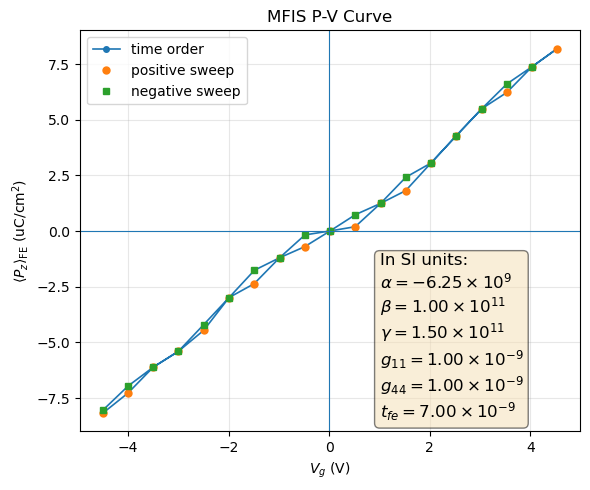

In [33]:
def sci_tex(x, sig=2):
    """Return LaTeX like 1.23\\times10^{-4} (no 'e')."""
    if x == 0:
        return r"0"
    exp = int(np.floor(np.log10(abs(x))))
    mant = x / (10 ** exp)
    return rf"{mant:.{sig}f}\times 10^{{{exp}}}"

# ==========================
# Plot PV curve
# ==========================

plt.figure(figsize=(6, 5))

textstr = '\n'.join((
    r'In SI units:',
    rf'$\alpha={sci_tex(ALPHA, sig=2)}$',
    rf'$\beta={sci_tex(BETA, sig=2)}$',
    rf'$\gamma={sci_tex(SMALL_GAMMA, sig=2)}$',
    rf'$g_{{11}}={sci_tex(G11, sig=2)}$',
    rf'$g_{{44}}={sci_tex(G44, sig=2)}$',
    rf'$t_{{fe}}={sci_tex((FE_Z_HI_NM-FE_Z_LO_NM)*1e-9, sig=2)}$',
))

props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(1, -1, textstr, fontsize=12,
        verticalalignment='top', bbox=props)

# time-order full loop
plt.plot(V, -P*100, "-o", markersize=4, linewidth=1.2, label="time order")
# paper data
#plt.plot(Vp, Pp, "-o", markersize=4, linewidth=1.2, label="paper")
# no f data
#plt.plot(Vnf, -Pnf*100, "-o", markersize=4, linewidth=1.2, label="before")
# optional: highlight positive / negative sweep
pos = df["sweep_direction"].to_numpy() >= 0
neg = df["sweep_direction"].to_numpy() < 0

if np.any(pos):
    plt.plot(V[pos], -P[pos]*100, "o", markersize=5, label="positive sweep")

if np.any(neg):
    plt.plot(V[neg], -P[neg]*100, "s", markersize=5, label="negative sweep")


plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(r"$V_g$ (V)")
plt.ylabel(r"$\langle P_z \rangle_\mathrm{FE}$ (uC/cm$^2$)")
plt.title("MFIS P-V Curve")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()

plt.savefig(OUT_FIG, dpi=200)
print(f"Saved figure: {OUT_FIG}")

plt.show()